FileNotFoundError: [Errno 2] No such file or directory: 'w11_algos.txt'

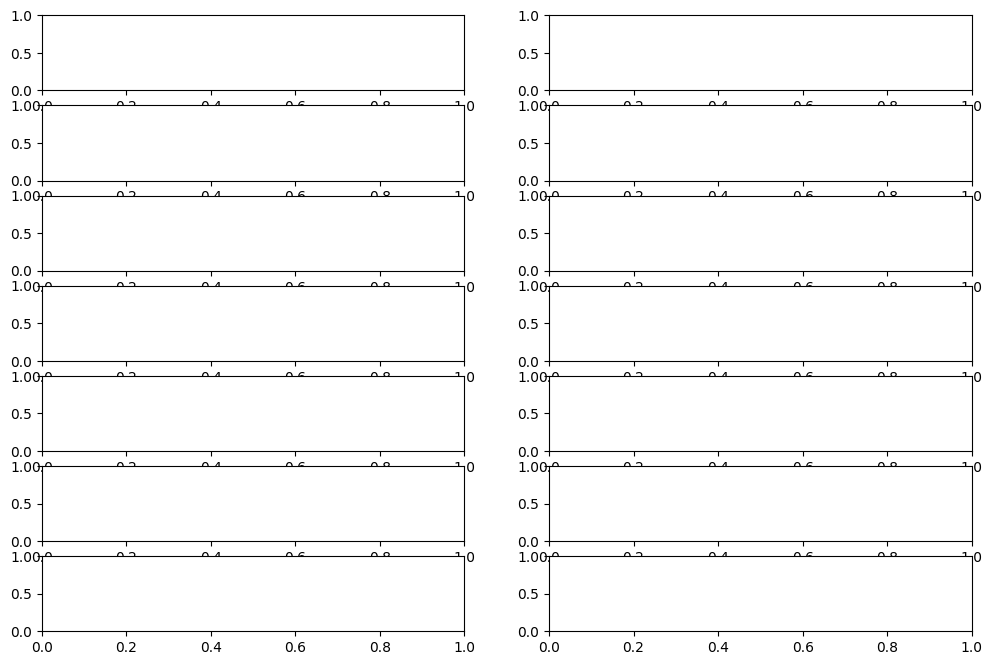

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ast
from collections import Counter

def plot_avgs(scenarios: list[str], ax):

    # Load strategies
    strategies = []
    for s in scenarios:
        with open(f'algos/{s}_algos.txt', 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    strategies.append(ast.literal_eval(line))

    strategies = np.array(strategies)
    avg_allocation = strategies.mean(axis=0)

    battlefields = [f'{i+1}' for i in range(len(avg_allocation))]

    bars = ax.bar(battlefields, avg_allocation,
                  color='#4C72B0', edgecolor='white', linewidth=0.5)

    # Add value labels
    for bar, val in zip(bars, avg_allocation):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}',
                ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Battlefield')
    ax.set_ylabel('Avg Soldiers')
    ax.set_title("+".join(scenarios))

    ax.spines[['top', 'right']].set_visible(False)

# ---- Create subplot grid ----

scenarios = [["w11"], ["w12"], ["w21"], ["w22"], ["w31"], ["w32"], ["w41"], ["w42"], ["w51"], ["w52"], ["w53"],
["w11", "w21"], "w11 w12 w21 w22 w31 w32 w41 w42 w51 w52 w53".split()]

fig, axes = plt.subplots(7, 2, figsize=(12, 8))

for ax, scenario in zip(axes.flatten(), scenarios):
    plot_avgs(scenario, ax)

fig.suptitle("Average Soldier Allocation Across Algorithms", fontsize=16)

plt.tight_layout()
plt.show()

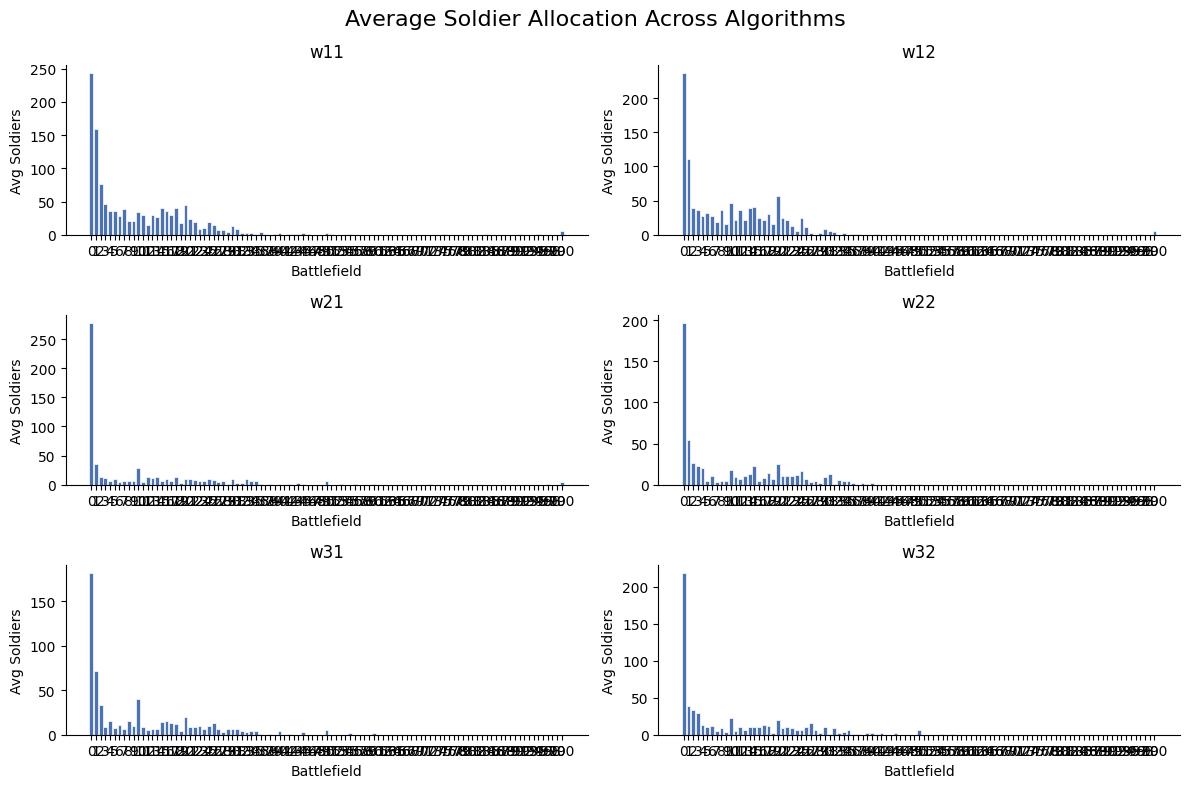

In [49]:
def plot_soldier_frequency(scenario: str, ax):

    # Load strategies
    soldier_freq = [0]*101
    with open(f'{scenario}_algos.txt', 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                for k in ast.literal_eval(line):
                    soldier_freq[k] += 1

    battlefields = [f'{i}' for i in range(len(soldier_freq))]

    bars = ax.bar(battlefields, soldier_freq,
                  color='#4C72B0', edgecolor='white', linewidth=0.5)

    ax.set_xlabel('Battlefield')
    ax.set_ylabel('Avg Soldiers')
    ax.set_title(scenario)

    ax.spines[['top', 'right']].set_visible(False)

fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for ax, scenario in zip(axes.flatten(), scenarios):
    plot_soldier_frequency(scenario, ax)

fig.suptitle("Average Soldier Allocation Across Algorithms", fontsize=16)

plt.tight_layout()
plt.show()


#top 3 of k=1500 
[0, 1, 7, 7, 4, 14, 17, 20, 27, 3], 826), ([0, 0, 5, 10, 10, 9, 16, 23, 23, 4], 685), ([0, 1, 5, 6, 1, 13, 13, 0, 27, 34], 671),


#top of k=1500 with pool += champion pool
[([1, 4, 1, 13, 5, 10, 14, 13, 10, 29], 279), ([1, 4, 1, 13, 5, 20, 14, 6, 16, 20], 255), ([1, 4, 1, 13, 5, 20, 14, 6, 16, 20], 255), ([1, 4, 1, 13, 5, 20, 14, 6, 16, 20], 255), ([0, 1, 1, 14, 5, 18, 14, 6, 16, 25], 243), ([0, 1, 1, 14, 5, 18, 14, 6, 16, 25], 243)
...
([0, 1, 7, 7, 4, 14, 17, 20, 27, 3], 86)

#funny w12 strategy z
[2, 2, 2, 2, 7, 27, 27, 27, 2, 2]

## w11 strategies
[2, 4, 6, 9, 11, 17, 24, 22, 2, 3]
[2, 4, 11, 2, 21, 22, 27, 2, 6, 3]
[2, 3, 3, 8, 11, 2, 22, 22, 24, 3]
[2, 3, 6, 9, 11, 15, 22, 27, 2, 3]

## w12 strategy optimized off w11 arena
[2, 4, 6, 8, 11, 21, 22, 22, 2, 2]

## w11 strategy optimized off w11+w12 arena
[2, 3, 3, 9, 2, 22, 23, 27, 6, 3]



# w21:
[0, 0, 0, 0, 0, 0, 0, 5, 44, 51] # mode=1
[0, 0, 0, 0, 3, 8, 32, 37, 18, 2] # mode-1 with w12_algos extend
[0, 0, 1, 2, 5, 7, 31, 34, 14, 6] mode-1 with good_algos extend
[0, 0, 0, 0, 1, 1, 22, 27, 26, 23] arena on w11+w12
[0, 0, 0, 0, 0, 1, 0, 5, 44, 50] # winner of good
[0, 0, 1, 2, 6, 13, 28, 9, 0, 41] # arena on good



theoretically optimal w21 strategy (optimized off w21)
[0, 0, 1, 2, 3, 2, 15, 35, 36, 6]


# w22:
[0, 1, 4, 15, 22, 22, 23, 2, 7, 4] # arena on w11+w12
[0, 2, 4, 11, 16, 21, 22, 21, 1, 2] # arena on w11

# w31:
[1, 4, 5, 1, 12, 15, 2, 1, 28, 31] arena off w11 min_soldiers=1
[0, 5, 6, 0, 12, 17, 2, 27, 28, 3] arena off w11
[0, 3, 4, 0, 17, 22, 0, 23, 28, 3] arena off w11+w12
[0, 2, 3, 0, 17, 22, 1, 23, 28, 4] arena off all
[2, 3, 3, 2, 2, 22, 24, 3, 28, 11] arena off all min_soldiers=2
[1, 2, 3, 1, 17, 22, 1, 23, 26, 4] arena off all but w21 min_soldiers=1
[1, 5, 7, 1, 11, 17, 3, 22, 31, 2] arena off w11 + some mode 1 samples

# w32:
    # [2, 5, 7, 2, 2, 23, 27, 24, 6, 2] arena off w11+w12
    # [2, 2, 2, 2, 2, 2, 23, 32, 29, 4] arena off all probably killed by w21
    # [2, 3, 3, 2, 2, 3, 25, 27, 28, 5] arena off all but w21 so maybe not
    # [2, 4, 6, 9, 11, 21, 25, 21, 1, 0] arena off w11

better w31 strategy optimized off w11+w21
[0, 3, 4, 0, 14, 17, 2, 27, 31, 2]

# w41:
    # [1, 2, 6, 9, 2, 22, 23, 27, 6, 2] arena w11+w12
    # [1, 1, 4, 5, 7, 4, 31, 1, 43, 3] arena w12
    # [1, 2, 3, 2, 2, 2, 27, 28, 31, 2] arena all
    # [1, 1, 4, 5, 7, 4, 31, 1, 43, 3] arena on w32
    # [1, 2, 3, 2, 2, 15, 22, 23, 28, 2] arena w11+w21
    # [1, 2, 3, 2, 3, 23, 27, 28, 7, 4] arena w12+w21

    # w42:
    # [2, 4, 3, 2, 2, 2, 23, 27, 3, 32] arena w11+w12 AND w11+w21 (yeah they gave the same strategy)
    # [2, 2, 3, 2, 3, 2, 23, 28, 3, 32] arena all
    # [2, 3, 3, 4, 4, 4, 22, 27, 28, 3] existing champion (ACTUALLY wins in w42)